Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13306


100%|██████████| 1000/1000 [10:26<00:00,  1.60it/s]



Saved: positional_head_scores.csv

BEST POSITIONAL ROLE FOR EACH HEAD
     Layer  Head BestPattern     Score
0        1     1        self  0.264781
1        1     2       prev1  0.092716
2        1     3        self  0.071077
3        1     4       prev1  0.259260
4        1     5       next1  0.074939
..     ...   ...         ...       ...
139     12     8        self  0.507810
140     12     9        self  0.996787
141     12    10        self  0.148416
142     12    11        self  0.980849
143     12    12        self  0.989983

[144 rows x 4 columns]


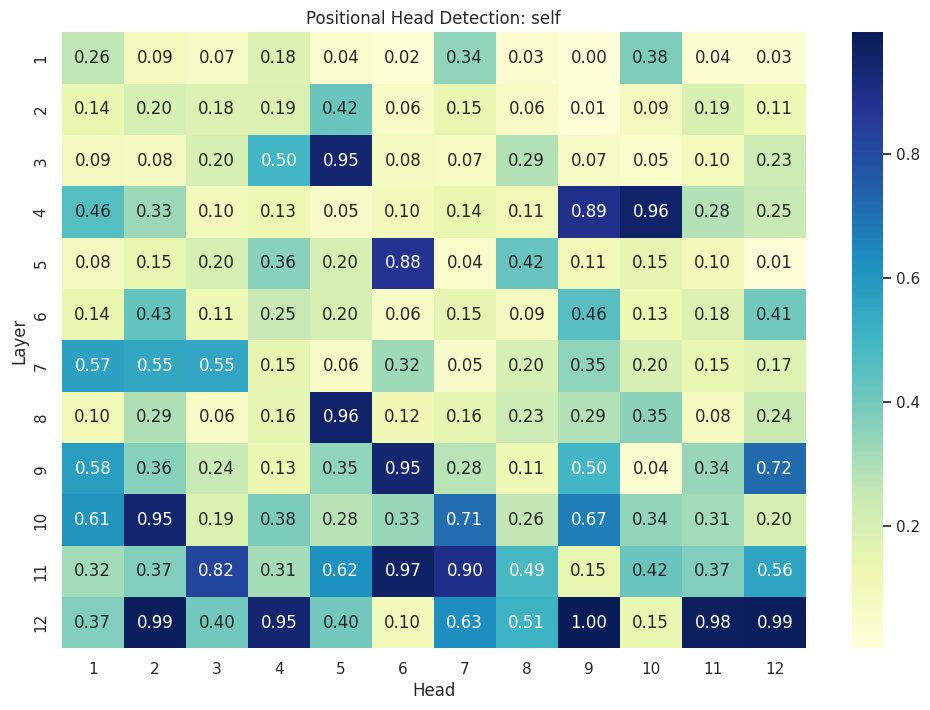

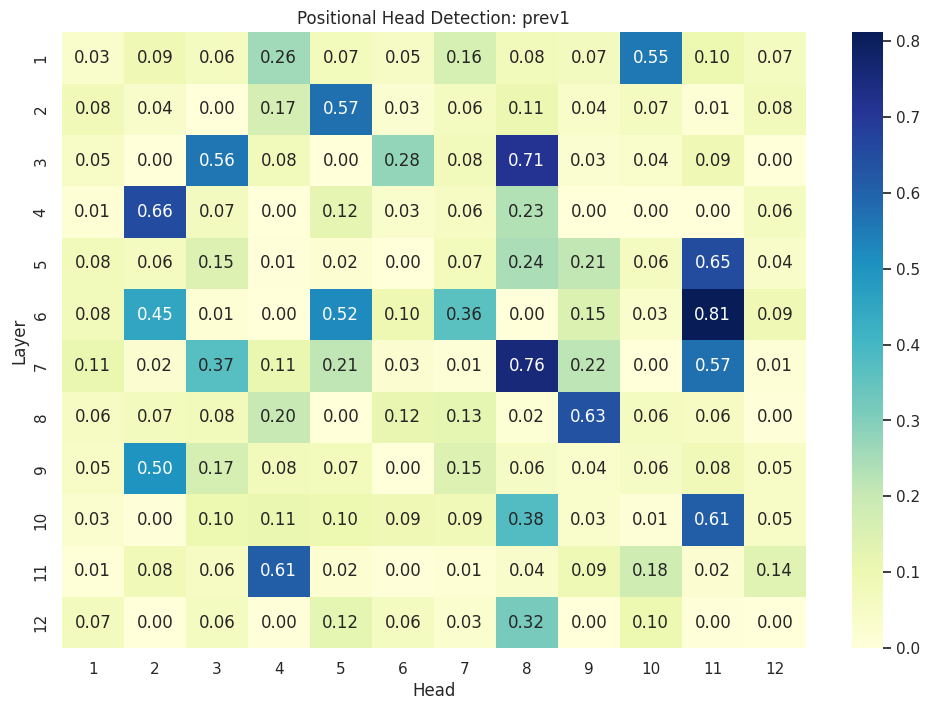

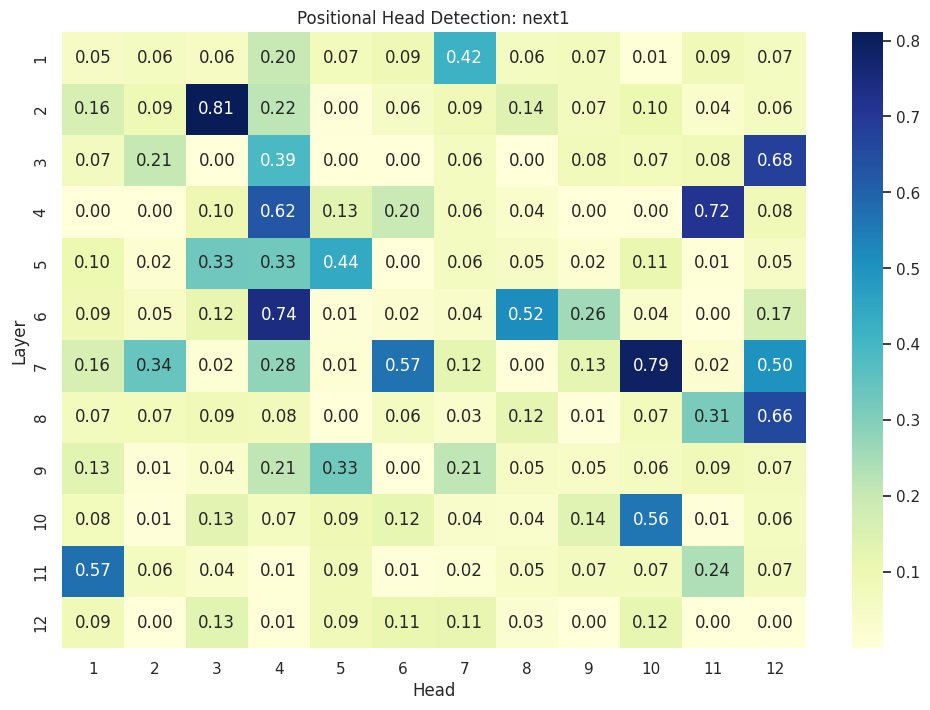

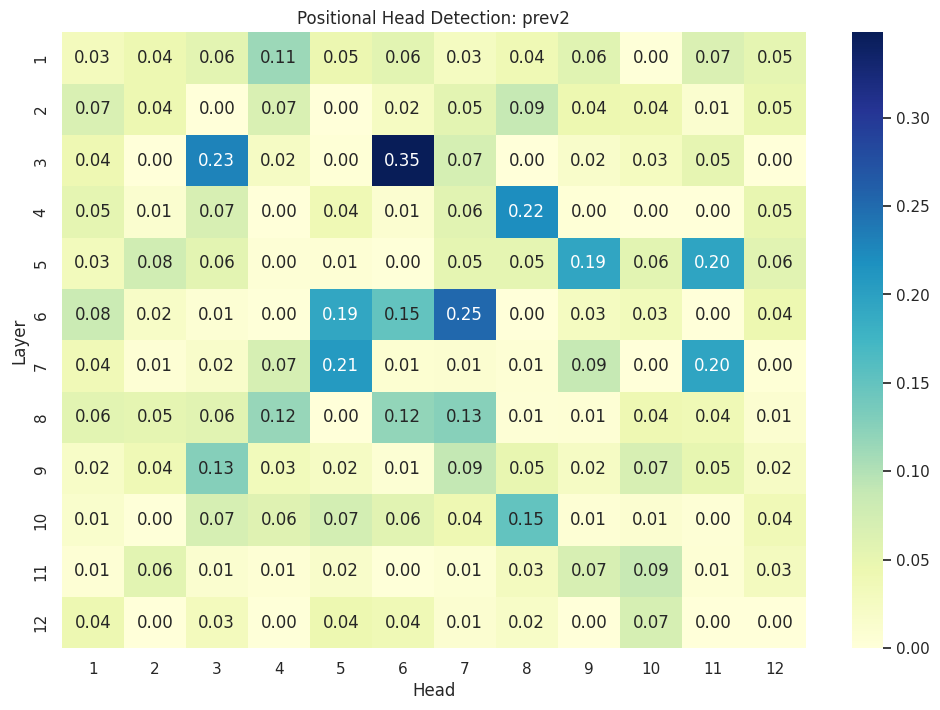

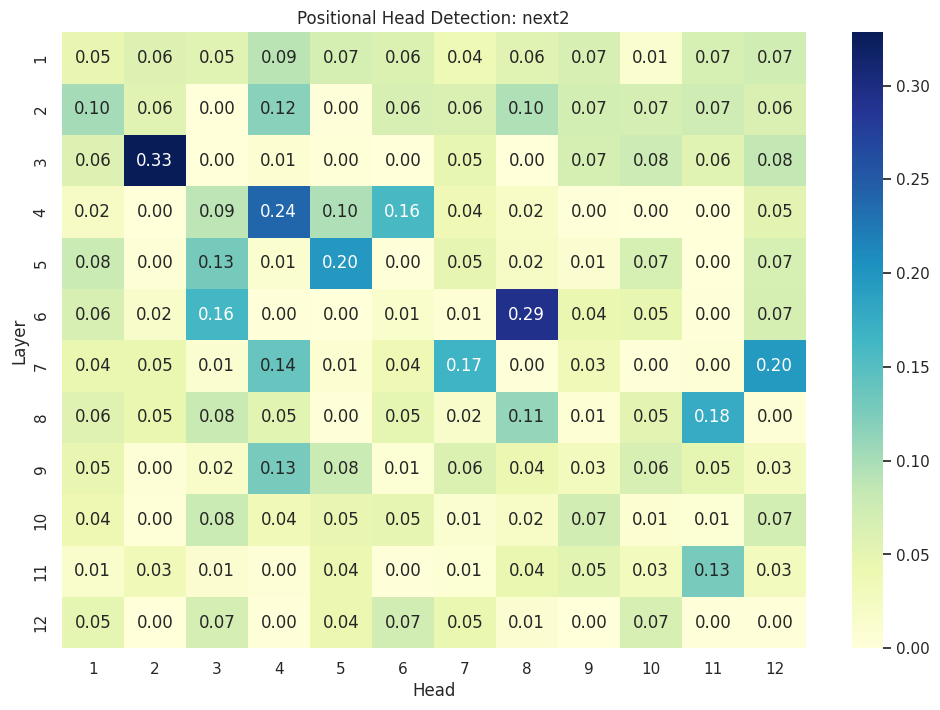

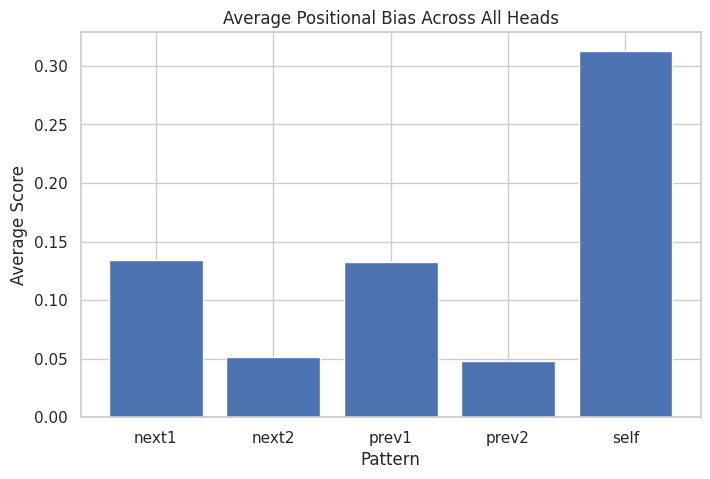


STRONGEST POSITIONAL HEAD OVERALL
Layer            12
Head              9
Pattern        self
Score      0.996787
Name: 704, dtype: object


In [1]:
# ==========================================================
# POSITIONAL HEAD DETECTION PIPELINE (BERT + UD DATASET)
# ----------------------------------------------------------
# Goal:
# Detect which BERT attention heads mainly attend by position:
#
# self   : token i   -> i
# prev1  : token i   -> i-1
# next1  : token i   -> i+1
# prev2  : token i   -> i-2
# next2  : token i   -> i+2
#
# Output:
# 1. Best positional pattern per head
# 2. Positional score tables
# 3. Heatmaps
# 4. CSV files
#
# Google Colab Ready
# ==========================================================

!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm

# ==========================================================
# IMPORTS
# ==========================================================
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==========================================================
# SETTINGS
# ==========================================================
MODEL_NAME = "bert-base-multilingual-cased"

DATASET_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu"

NUM_SENTENCES = 1000

MAX_LEN_WORDS = 40

PATTERNS = ["self", "prev1", "next1", "prev2", "next2"]

# ==========================================================
# LOAD MODEL
# ==========================================================
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.to(device)
model.eval()

# ==========================================================
# LOAD DATASET
# ==========================================================
print("Downloading dataset...")

data = requests.get(DATASET_URL).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))

# ==========================================================
# WORD -> SUBWORD ALIGNMENT
# ==========================================================
def tokenize_with_alignment(words):

    bert_tokens = ["[CLS]"]
    mapping = {}

    pos = 1

    for i, word in enumerate(words, start=1):

        subs = tokenizer.tokenize(word)

        if len(subs) == 0:
            subs = ["[UNK]"]

        mapping[i] = list(range(pos, pos + len(subs)))

        bert_tokens.extend(subs)
        pos += len(subs)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping


# ==========================================================
# GET ATTENTION
# ==========================================================
def get_attention(words):

    sent = " ".join(words)

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.attentions


# ==========================================================
# TOKEN MATRIX -> WORD MATRIX
# ==========================================================
def convert_to_word_matrix(token_matrix, mapping, n_words):

    word_matrix = np.zeros((n_words+1, n_words+1))

    for child in range(1, n_words+1):

        child_tokens = mapping[child]

        for parent in range(1, n_words+1):

            parent_tokens = mapping[parent]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(token_matrix[ct][pt])

            word_matrix[child][parent] = np.mean(vals)

    return word_matrix


# ==========================================================
# POSITIONAL SCORE FUNCTION
# ==========================================================
def positional_scores(word_matrix, n_words):

    counts = {
        "self": 0,
        "prev1": 0,
        "next1": 0,
        "prev2": 0,
        "next2": 0
    }

    total = 0

    for i in range(1, n_words + 1):

        row = word_matrix[i][1:]   # ignore zero index
        pred = np.argmax(row) + 1  # best attended word

        total += 1

        if pred == i:
            counts["self"] += 1
        if pred == i - 1:
            counts["prev1"] += 1
        if pred == i + 1:
            counts["next1"] += 1
        if pred == i - 2:
            counts["prev2"] += 1
        if pred == i + 2:
            counts["next2"] += 1

    if total == 0:
        return None

    for k in counts:
        counts[k] = counts[k] / total

    return counts


# ==========================================================
# MAIN LOOP
# ==========================================================
results = []

for idx in tqdm(range(min(NUM_SENTENCES, len(sentences)))):

    try:
        sent = sentences[idx]

        words = []

        for tok in sent:
            if isinstance(tok["id"], int):
                words.append(tok["form"])

        if len(words) < 3:
            continue

        if len(words) > MAX_LEN_WORDS:
            continue

        attentions = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        n_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    n_words
                )

                scores = positional_scores(
                    word_matrix,
                    n_words
                )

                if scores is not None:
                    for pattern in PATTERNS:

                        results.append([
                            layer + 1,
                            head + 1,
                            pattern,
                            scores[pattern]
                        ])

    except:
        continue

# ==========================================================
# DATAFRAME
# ==========================================================
df = pd.DataFrame(
    results,
    columns=["Layer", "Head", "Pattern", "Score"]
)

avg_df = df.groupby(
    ["Layer", "Head", "Pattern"]
)["Score"].mean().reset_index()

avg_df.to_csv("positional_head_scores.csv", index=False)

print("\nSaved: positional_head_scores.csv")

# ==========================================================
# BEST PATTERN FOR EACH HEAD
# ==========================================================
print("\n===================================")
print("BEST POSITIONAL ROLE FOR EACH HEAD")
print("===================================")

summary_rows = []

for layer in range(1, 13):
    for head in range(1, 13):

        sub = avg_df[
            (avg_df["Layer"] == layer) &
            (avg_df["Head"] == head)
        ]

        if len(sub) == 0:
            continue

        best = sub.sort_values(
            "Score",
            ascending=False
        ).iloc[0]

        summary_rows.append([
            layer,
            head,
            best["Pattern"],
            best["Score"]
        ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Layer", "Head", "BestPattern", "Score"]
)

print(summary_df)

summary_df.to_csv(
    "best_positional_role_per_head.csv",
    index=False
)

# ==========================================================
# HEATMAP FOR EACH PATTERN
# ==========================================================
for pattern in PATTERNS:

    sub = avg_df[
        avg_df["Pattern"] == pattern
    ]

    pivot = sub.pivot(
        index="Layer",
        columns="Head",
        values="Score"
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title(f"Positional Head Detection: {pattern}")
    plt.xlabel("Head")
    plt.ylabel("Layer")

    plt.show()

# ==========================================================
# BAR CHART OF GLOBAL PATTERN STRENGTH
# ==========================================================
global_avg = avg_df.groupby(
    "Pattern"
)["Score"].mean().reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    global_avg["Pattern"],
    global_avg["Score"]
)

plt.title("Average Positional Bias Across All Heads")
plt.xlabel("Pattern")
plt.ylabel("Average Score")
plt.show()

# ==========================================================
# STRONGEST POSITIONAL HEAD OVERALL
# ==========================================================
best = avg_df.sort_values(
    "Score",
    ascending=False
).iloc[0]

print("\n===================================")
print("STRONGEST POSITIONAL HEAD OVERALL")
print("===================================")
print(best)

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13813


100%|██████████| 1000/1000 [06:08<00:00,  2.72it/s]



Saved: positional_head_scores.csv

BEST POSITIONAL ROLE FOR EACH HEAD
     Layer  Head BestPattern     Score
0        1     1        self  0.330847
1        1     2        self  0.228561
2        1     3       next1  0.105885
3        1     4       prev1  0.220003
4        1     5       next1  0.102220
..     ...   ...         ...       ...
139     12     8        self  0.479404
140     12     9        self  0.992886
141     12    10        self  0.203321
142     12    11        self  0.973577
143     12    12        self  0.989537

[144 rows x 4 columns]


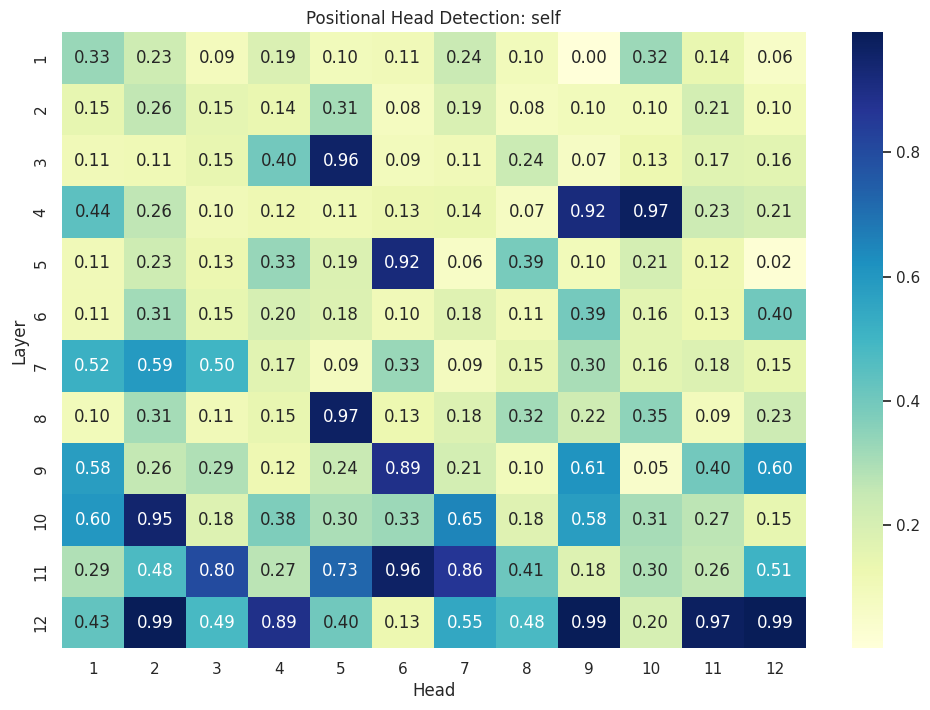

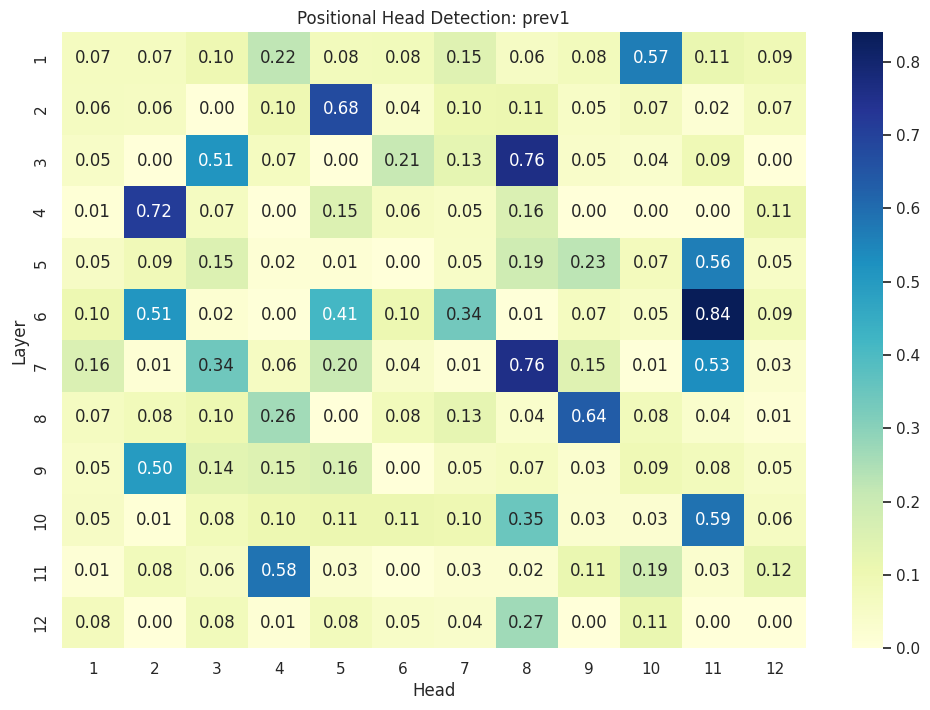

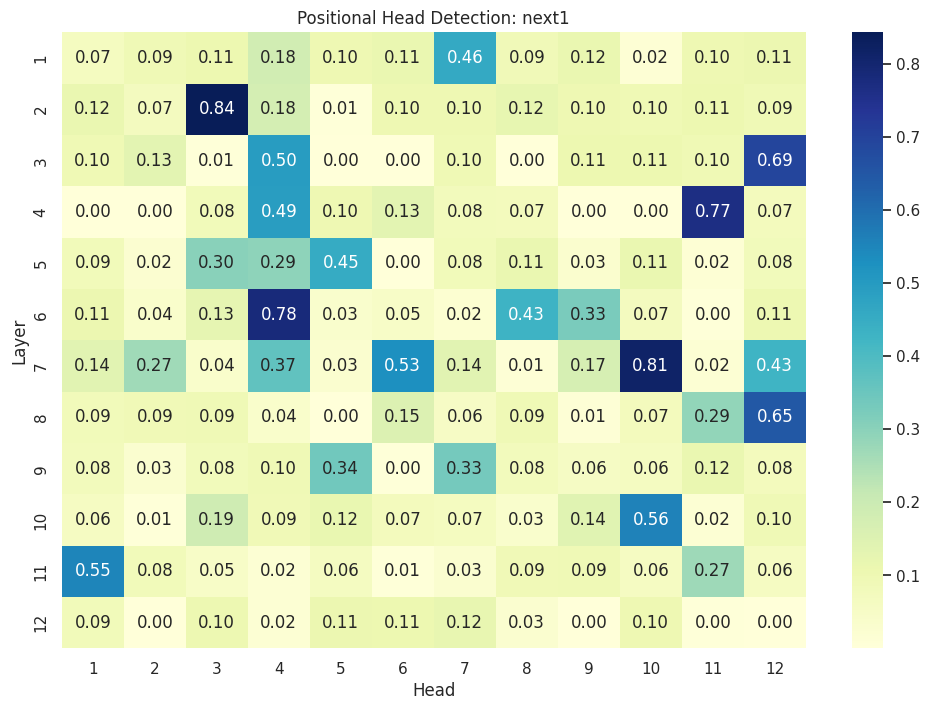

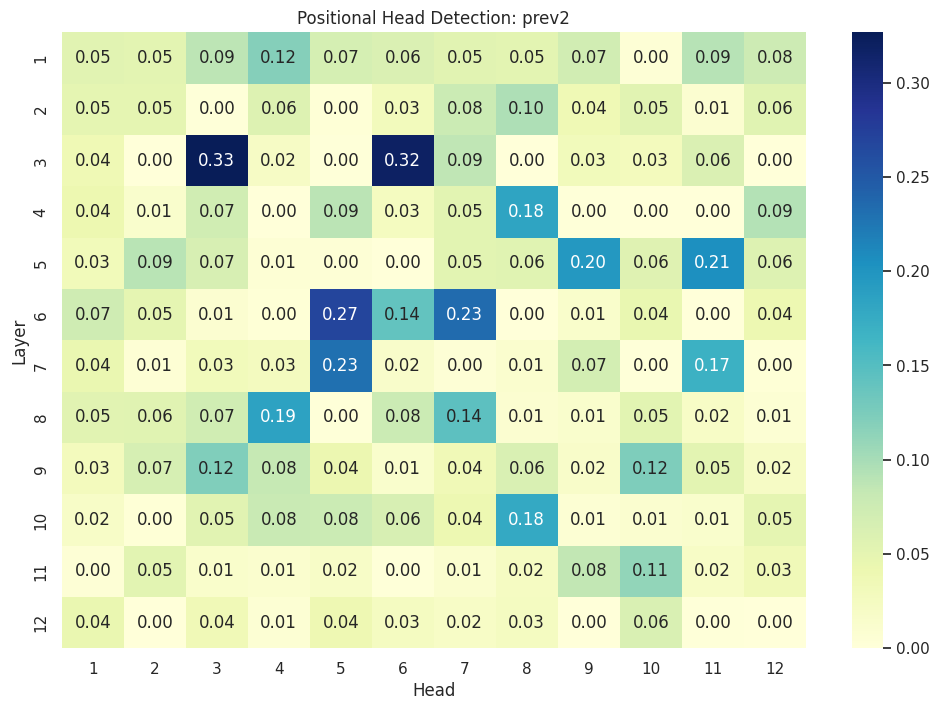

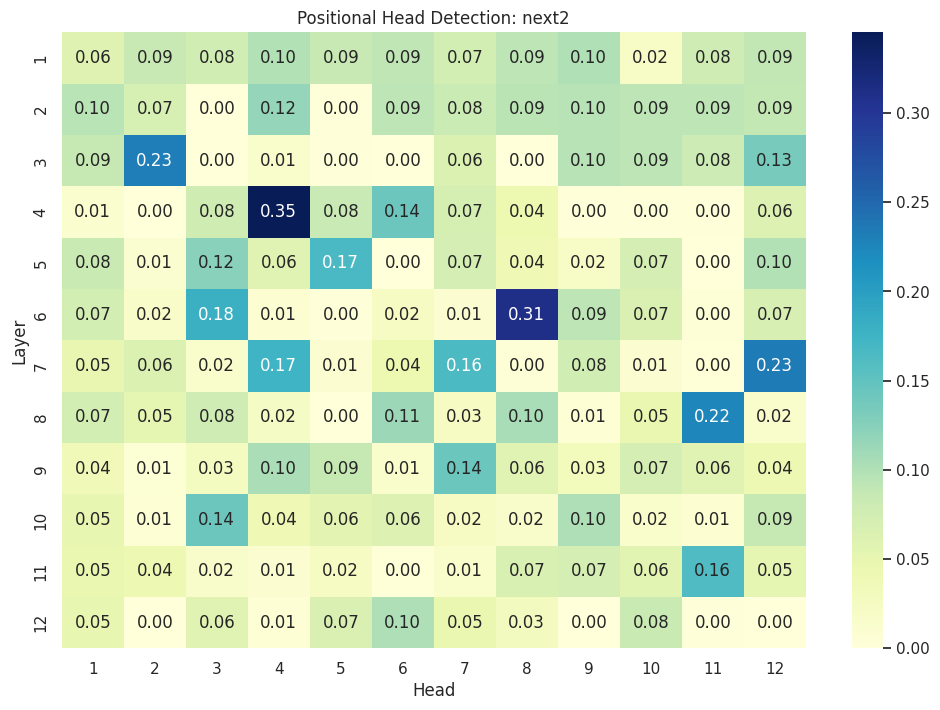

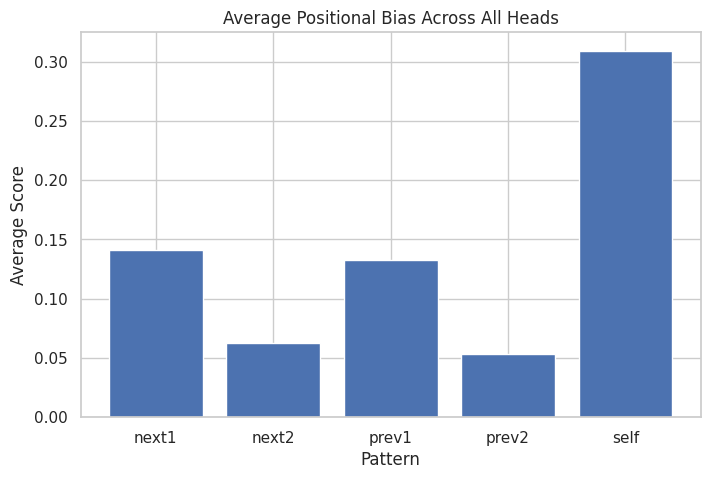


STRONGEST POSITIONAL HEAD OVERALL
Layer            12
Head              9
Pattern        self
Score      0.992886
Name: 704, dtype: object


In [2]:
# ==========================================================
# POSITIONAL HEAD DETECTION PIPELINE (BERT + UD DATASET)
# ----------------------------------------------------------
# Goal:
# Detect which BERT attention heads mainly attend by position:
#
# self   : token i   -> i
# prev1  : token i   -> i-1
# next1  : token i   -> i+1
# prev2  : token i   -> i-2
# next2  : token i   -> i+2
#
# Output:
# 1. Best positional pattern per head
# 2. Positional score tables
# 3. Heatmaps
# 4. CSV files
#
# Google Colab Ready
# ==========================================================

!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm

# ==========================================================
# IMPORTS
# ==========================================================
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==========================================================
# SETTINGS
# ==========================================================
MODEL_NAME = "bert-base-multilingual-cased"

DATASET_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu"
PATTERNS = ["self", "prev1", "next1", "prev2", "next2"]

# ==========================================================
# LOAD MODEL
# ==========================================================
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.to(device)
model.eval()

# ==========================================================
# LOAD DATASET
# ==========================================================
print("Downloading dataset...")

data = requests.get(DATASET_URL).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))

# ==========================================================
# WORD -> SUBWORD ALIGNMENT
# ==========================================================
def tokenize_with_alignment(words):

    bert_tokens = ["[CLS]"]
    mapping = {}

    pos = 1

    for i, word in enumerate(words, start=1):

        subs = tokenizer.tokenize(word)

        if len(subs) == 0:
            subs = ["[UNK]"]

        mapping[i] = list(range(pos, pos + len(subs)))

        bert_tokens.extend(subs)
        pos += len(subs)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping


# ==========================================================
# GET ATTENTION
# ==========================================================
def get_attention(words):

    sent = " ".join(words)

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.attentions


# ==========================================================
# TOKEN MATRIX -> WORD MATRIX
# ==========================================================
def convert_to_word_matrix(token_matrix, mapping, n_words):

    word_matrix = np.zeros((n_words+1, n_words+1))

    for child in range(1, n_words+1):

        child_tokens = mapping[child]

        for parent in range(1, n_words+1):

            parent_tokens = mapping[parent]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(token_matrix[ct][pt])

            word_matrix[child][parent] = np.mean(vals)

    return word_matrix


# ==========================================================
# POSITIONAL SCORE FUNCTION
# ==========================================================
def positional_scores(word_matrix, n_words):

    counts = {
        "self": 0,
        "prev1": 0,
        "next1": 0,
        "prev2": 0,
        "next2": 0
    }

    total = 0

    for i in range(1, n_words + 1):

        row = word_matrix[i][1:]   # ignore zero index
        pred = np.argmax(row) + 1  # best attended word

        total += 1

        if pred == i:
            counts["self"] += 1
        if pred == i - 1:
            counts["prev1"] += 1
        if pred == i + 1:
            counts["next1"] += 1
        if pred == i - 2:
            counts["prev2"] += 1
        if pred == i + 2:
            counts["next2"] += 1

    if total == 0:
        return None

    for k in counts:
        counts[k] = counts[k] / total

    return counts


# ==========================================================
# MAIN LOOP
# ==========================================================
results = []

for idx in tqdm(range(min(NUM_SENTENCES, len(sentences)))):

    try:
        sent = sentences[idx]

        words = []

        for tok in sent:
            if isinstance(tok["id"], int):
                words.append(tok["form"])

        if len(words) < 3:
            continue

        if len(words) > MAX_LEN_WORDS:
            continue

        attentions = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        n_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    n_words
                )

                scores = positional_scores(
                    word_matrix,
                    n_words
                )

                if scores is not None:
                    for pattern in PATTERNS:

                        results.append([
                            layer + 1,
                            head + 1,
                            pattern,
                            scores[pattern]
                        ])

    except:
        continue

# ==========================================================
# DATAFRAME
# ==========================================================
df = pd.DataFrame(
    results,
    columns=["Layer", "Head", "Pattern", "Score"]
)

avg_df = df.groupby(
    ["Layer", "Head", "Pattern"]
)["Score"].mean().reset_index()

avg_df.to_csv("positional_head_scores.csv", index=False)

print("\nSaved: positional_head_scores.csv")

# ==========================================================
# BEST PATTERN FOR EACH HEAD
# ==========================================================
print("\n===================================")
print("BEST POSITIONAL ROLE FOR EACH HEAD")
print("===================================")

summary_rows = []

for layer in range(1, 13):
    for head in range(1, 13):

        sub = avg_df[
            (avg_df["Layer"] == layer) &
            (avg_df["Head"] == head)
        ]

        if len(sub) == 0:
            continue

        best = sub.sort_values(
            "Score",
            ascending=False
        ).iloc[0]

        summary_rows.append([
            layer,
            head,
            best["Pattern"],
            best["Score"]
        ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Layer", "Head", "BestPattern", "Score"]
)

print(summary_df)

summary_df.to_csv(
    "best_positional_role_per_head.csv",
    index=False
)

# ==========================================================
# HEATMAP FOR EACH PATTERN
# ==========================================================
for pattern in PATTERNS:

    sub = avg_df[
        avg_df["Pattern"] == pattern
    ]

    pivot = sub.pivot(
        index="Layer",
        columns="Head",
        values="Score"
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu"
    )

    plt.title(f"Positional Head Detection: {pattern}")
    plt.xlabel("Head")
    plt.ylabel("Layer")

    plt.show()

# ==========================================================
# BAR CHART OF GLOBAL PATTERN STRENGTH
# ==========================================================
global_avg = avg_df.groupby(
    "Pattern"
)["Score"].mean().reset_index()

plt.figure(figsize=(8,5))

plt.bar(
    global_avg["Pattern"],
    global_avg["Score"]
)

plt.title("Average Positional Bias Across All Heads")
plt.xlabel("Pattern")
plt.ylabel("Average Score")
plt.show()

# ==========================================================
# STRONGEST POSITIONAL HEAD OVERALL
# ==========================================================
best = avg_df.sort_values(
    "Score",
    ascending=False
).iloc[0]

print("\n===================================")
print("STRONGEST POSITIONAL HEAD OVERALL")
print("===================================")
print(best)

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13813

Sample Sentence:
['Sehr', 'gute', 'Beratung', ',', 'schnelle', 'Behebung', 'der', 'Probleme', ',', 'so', 'stelle', 'ich', 'mir', 'Kundenservice', 'vor', '.']

BERT Tokens:
['[CLS]', 'Se', '##hr', 'gute', 'Be', '##ratu', '##ng', ',', 'schnell', '##e', 'Be', '##hebung', 'der', 'Probleme', ',', 'so', 'stelle', 'ich', 'mir', 'Kunden', '##ser', '##vice', 'vor', '.', '[SEP]']

Alignment Mapping:
{1: [1, 2], 2: [3], 3: [4, 5, 6], 4: [7], 5: [8, 9], 6: [10, 11], 7: [12], 8: [13], 9: [14], 10: [15], 11: [16], 12: [17], 13: [18], 14: [19, 20, 21], 15: [22], 16: [23]}


100%|██████████| 1000/1000 [06:10<00:00,  2.70it/s]



BEST HEAD FOUND:
Layer       7.000000
Head        9.000000
Accuracy    0.620486
Name: 80, dtype: float64


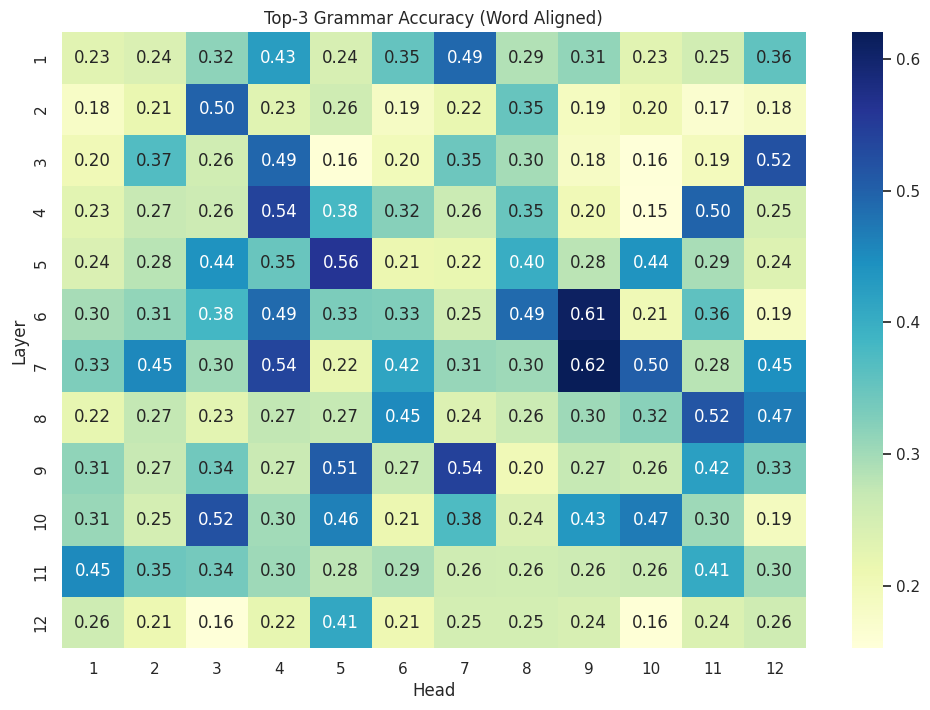

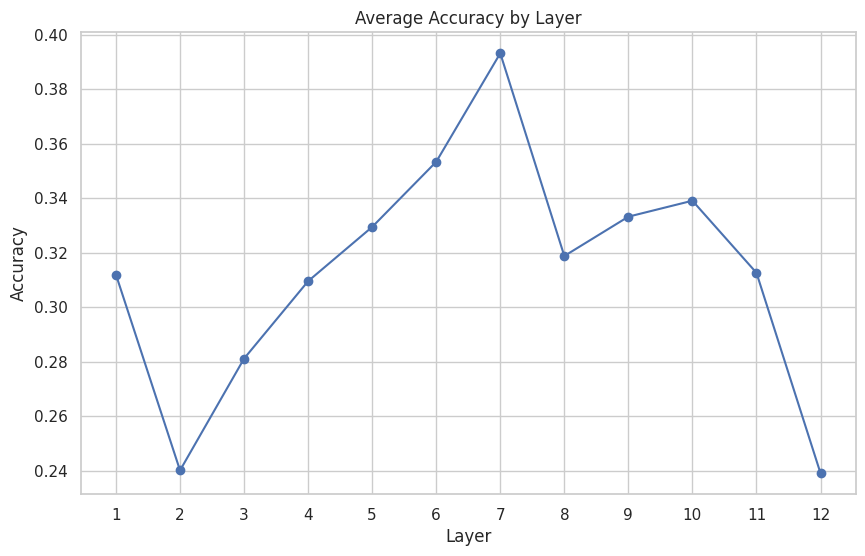


Saved File: bert_top3_word_aligned_results.csv


In [3]:
# ==========================================================
# VERSION 2 CODE
# Improvements Added:
# 1. Top-3 scoring instead of Top-1
# 2. Subword-to-word alignment for BERT tokens
# ==========================================================

!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm

# -----------------------------
# IMPORTS
# -----------------------------
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==========================================================
# LOAD BERT
# ==========================================================
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

model = BertModel.from_pretrained(
    "bert-base-multilingual-cased",
    output_attentions=True
)

model.to(device)
model.eval()

# ==========================================================
# LOAD UNIVERSAL DEPENDENCIES DATASET
# ==========================================================
url = "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu"
data = requests.get(url).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))

# ==========================================================
# FUNCTION: WORD -> SUBWORD ALIGNMENT
# ==========================================================
def tokenize_with_alignment(words):
    """
    Converts word list into BERT tokens
    Also stores mapping:
    word index -> list of subword token positions
    """

    bert_tokens = ["[CLS]"]
    mapping = {}

    current_pos = 1   # because CLS at 0

    for i, word in enumerate(words, start=1):

        sub_tokens = tokenizer.tokenize(word)

        mapping[i] = list(range(current_pos, current_pos + len(sub_tokens)))

        bert_tokens.extend(sub_tokens)

        current_pos += len(sub_tokens)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping


# ==========================================================
# FUNCTION: GET ATTENTION
# ==========================================================
def get_attention(words):

    sentence = " ".join(words)

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions

    bert_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    return attentions, bert_tokens


# ==========================================================
# FUNCTION: SUBWORD -> WORD MATRIX
# ==========================================================
def convert_to_word_matrix(attn_matrix, mapping, num_words):
    """
    Converts token-token attention matrix
    into word-word attention matrix
    by averaging subword attentions
    """

    word_matrix = np.zeros((num_words+1, num_words+1))

    for child_word in range(1, num_words+1):

        child_tokens = mapping[child_word]

        for parent_word in range(1, num_words+1):

            parent_tokens = mapping[parent_word]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(attn_matrix[ct][pt])

            word_matrix[child_word][parent_word] = np.mean(vals)

    return word_matrix


# ==========================================================
# FUNCTION: TOP-3 SCORE
# ==========================================================
def top3_score(word_matrix, gold_heads):
    """
    If gold parent in top 3 attention targets => correct
    """

    correct = 0
    total = 0

    num_words = len(gold_heads)

    for child in range(1, num_words+1):

        gold_parent = gold_heads[child-1]

        if gold_parent == 0:
            continue

        row = word_matrix[child][1:]  # ignore index 0

        top3 = np.argsort(row)[-3:] + 1

        if gold_parent in top3:
            correct += 1

        total += 1

    if total == 0:
        return 0

    return correct / total


# ==========================================================
# TEST ONE SENTENCE
# ==========================================================
sample = sentences[0]

words = [token["form"] for token in sample]
heads = [token["head"] for token in sample]

print("\nSample Sentence:")
print(words)

attentions, bert_tokens = get_attention(words)

print("\nBERT Tokens:")
print(bert_tokens)

bert_tokens2, mapping = tokenize_with_alignment(words)

print("\nAlignment Mapping:")
print(mapping)

# ==========================================================
# MAIN LOOP
# ==========================================================
NUM_SENTENCES = 1000

all_scores = []

for idx in tqdm(range(NUM_SENTENCES)):

    try:
        sample = sentences[idx]

        words = [token["form"] for token in sample]
        heads = [token["head"] for token in sample]

        # skip very short
        if len(words) < 3:
            continue

        # skip too long
        if len(words) > 40:
            continue

        attentions, bert_tokens = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        num_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    num_words
                )

                acc = top3_score(word_matrix, heads)

                all_scores.append([layer+1, head+1, acc])

    except:
        continue

# ==========================================================
# RESULTS DATAFRAME
# ==========================================================
df = pd.DataFrame(
    all_scores,
    columns=["Layer", "Head", "Accuracy"]
)

avg_df = df.groupby(
    ["Layer","Head"]
)["Accuracy"].mean().reset_index()

# ==========================================================
# BEST HEAD
# ==========================================================
best = avg_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("\nBEST HEAD FOUND:")
print(best)

# ==========================================================
# HEATMAP
# ==========================================================
pivot = avg_df.pivot(
    index="Layer",
    columns="Head",
    values="Accuracy"
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Top-3 Grammar Accuracy (Word Aligned)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()

# ==========================================================
# LAYER GRAPH
# ==========================================================
layer_avg = avg_df.groupby("Layer")["Accuracy"].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(
    layer_avg["Layer"],
    layer_avg["Accuracy"],
    marker="o"
)

plt.title("Average Accuracy by Layer")
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.xticks(range(1,13))
plt.show()

# ==========================================================
# SAVE CSV
# ==========================================================
avg_df.to_csv("bert_top3_word_aligned_results.csv", index=False)

print("\nSaved File: bert_top3_word_aligned_results.csv")